<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Import-Standard-Data-Science-Packages" data-toc-modified-id="Import-Standard-Data-Science-Packages-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Import Standard Data Science Packages</a></span><ul class="toc-item"><li><span><a href="#Set-Colorblind-Friendly-Palette" data-toc-modified-id="Set-Colorblind-Friendly-Palette-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Set Colorblind-Friendly Palette</a></span></li></ul></li><li><span><a href="#Load-and-Visualise-dPCR-Data" data-toc-modified-id="Load-and-Visualise-dPCR-Data-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Load and Visualise dPCR Data</a></span></li><li><span><a href="#Data-Analysis" data-toc-modified-id="Data-Analysis-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Data Analysis</a></span><ul class="toc-item"><li><span><a href="#Organise-Data" data-toc-modified-id="Organise-Data-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Organise Data</a></span></li><li><span><a href="#Define-ACA-Model-(Neural-Network)" data-toc-modified-id="Define-ACA-Model-(Neural-Network)-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Define ACA Model (Neural Network)</a></span></li><li><span><a href="#Train-and-Compute-Performance-(10-Fold-Cross-Val)" data-toc-modified-id="Train-and-Compute-Performance-(10-Fold-Cross-Val)-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>Train and Compute Performance (10-Fold Cross Val)</a></span></li><li><span><a href="#Visualise-AMCA-Coefficients" data-toc-modified-id="Visualise-AMCA-Coefficients-3.4"><span class="toc-item-num">3.4&nbsp;&nbsp;</span>Visualise AMCA Coefficients</a></span></li><li><span><a href="#Compute-Performance-as-a-Function-of-Training-Volume" data-toc-modified-id="Compute-Performance-as-a-Function-of-Training-Volume-3.5"><span class="toc-item-num">3.5&nbsp;&nbsp;</span>Compute Performance as a Function of Training Volume</a></span></li></ul></li></ul></div>

# Import Standard Data Science Packages

In [1]:
%load_ext autoreload
%autoreload
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from pathlib import Path

import chip_utilities as utils

/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/3. Initial code/titan-signal-processing-main/venv_titan/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Set Colorblind-Friendly Palette

In [2]:
import matplotlib as mpl
from cycler import cycler
from matplotlib.colors import to_hex
mpl.rcParams['axes.prop_cycle'] = cycler(color=[to_hex(i) for i in
                                                [(0, 0.45, 0.70),    # Blue
                                                (0.9, 0.6, 0.0),     # Orange
                                                (0.0, 0.60, 0.50),    # Bluish Green
                                                (0.8, 0.4, 0),       # Vermillion/Burnt Orange
                                                (0.35, 0.7, 0.9),    # Sky Blue
                                                (0.8, 0.6, 0.7),     # Reddish Purple/Pink
                                                (0, 0, 0),           # Black
                                                (0.5, 0.5, 0.5),     # Grey
                                                (0.286, 0, 0.573),   # Deep Purple
                                                (0.8, 0.1, 0.3)]])   # 10th: Berry Red

# Load and Visualise dPCR Data

In [3]:
exp_folder = "/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/Run Data/trial test data/"
exp_path = Path(exp_folder, "D20250808_E00_C00_F4500KHz_U_Sample_7")
sigmoid_data_path = f'{exp_path}/normalised_ori_ac_df.csv'

chip_data = pd.read_csv(sigmoid_data_path)
chip_data = utils.denormalized(chip_data)
chip_data.head()

,row_min,row_max,row_range,well,Cycle71.10000000000001,Cycle74.89999999999999,Cycle78.7,Cycle82.49999999999999,Cycle86.3,Cycle90.10000000000001,...,Cycle2364.4,Cycle2368.2000000000003,Cycle2372.0,Cycle2375.8,Cycle2379.6000000000004,Cycle2383.4,Cycle2387.1000000000004,Cycle2390.9,Cycle2394.7000000000003,Cycle2398.5
0,0.209451,0.239304,0.029854,0,0.219883,0.225581,0.221032,0.223199,0.226792,0.220374,...,0.237564,0.233608,0.236609,0.236990,0.234911,0.234537,0.236800,0.237373,0.238334,0.233423
1,0.197048,0.227095,0.030047,0,0.219883,0.225896,0.222948,0.219505,0.218379,0.214700,...,0.223727,0.223143,0.222368,0.219316,0.215609,0.224511,0.221597,0.225499,0.223923,0.226494
2,0.190823,0.223456,0.032633,0,0.219883,0.215283,0.218522,0.220078,0.218136,0.211950,...,0.221062,0.219298,0.223255,0.216987,0.221062,0.220864,0.221259,0.222253,0.221259,0.223456
3,0.201863,0.221085,0.019222,0,0.219883,0.218566,0.215485,0.221085,0.219090,0.216118,...,0.214233,0.215359,0.215233,0.216373,0.212877,0.213738,0.213245,0.216245,0.214607,0.210822
4,0.203428,0.228837,0.025409,0,0.219883,0.223504,0.219256,0.222212,0.222212,0.211433,...,0.227704,0.225473,0.226359,0.224812,0.225473,0.224593,0.228837,0.226137,0.225473,0.225915


In [4]:
y_lim_min, y_lim_max = chip_data.filter(like="Cycle").values.min(), chip_data.filter(like="Cycle").values.max()

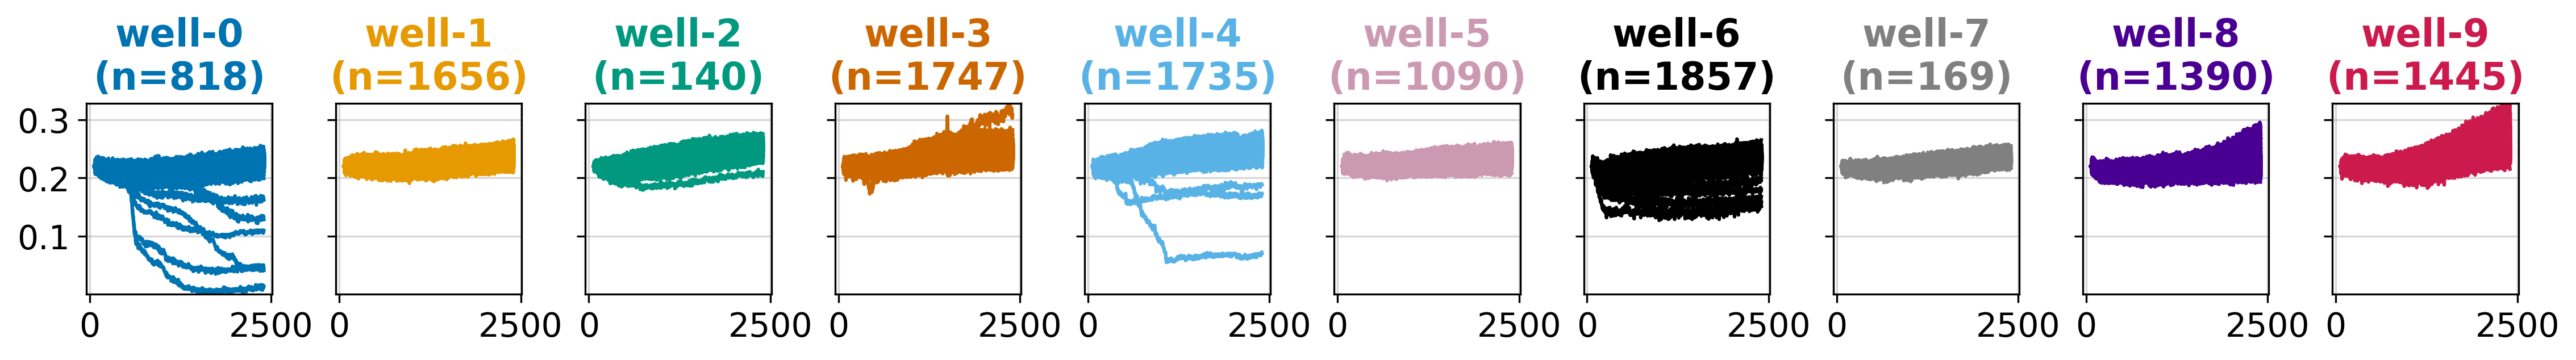

In [5]:
utils.plot_amplification_curves(chip_data, ylim=(y_lim_min, y_lim_max))

In [6]:
# filename = 'Images/dPCR_melting_peaks.png'
# utils.plot_melt_peak_distributions(df_dpcr_ampl, filename=filename)

In [7]:
# df_dpcr_melt = pd.read_csv('Data/dPCR_Melting_Curves.csv', 
#                            index_col=0)

# df_dpcr_melt.head()

In [8]:
# filename = 'Images/dPCR_melting_curves.png'
# utils.plot_melt_curves(df_dpcr_melt, NMETA=7, ylim=(0, 0.12), filename=filename)

# Data Analysis
## Organise Data

In [9]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegressionCV

X_AC = chip_data.filter(like="Cycle").values
# X_MC = df_dpcr_ampl.loc[:, ['MeltPeaks']].values
X_FFI = X_AC[:,[-1]]

encoder = LabelEncoder()
encoder.fit(chip_data['well'])
ytrue = encoder.transform(chip_data['well'])

X_AC.shape, X_FFI.shape, ytrue.shape

((12047, 615), (12047, 1), (12047,))

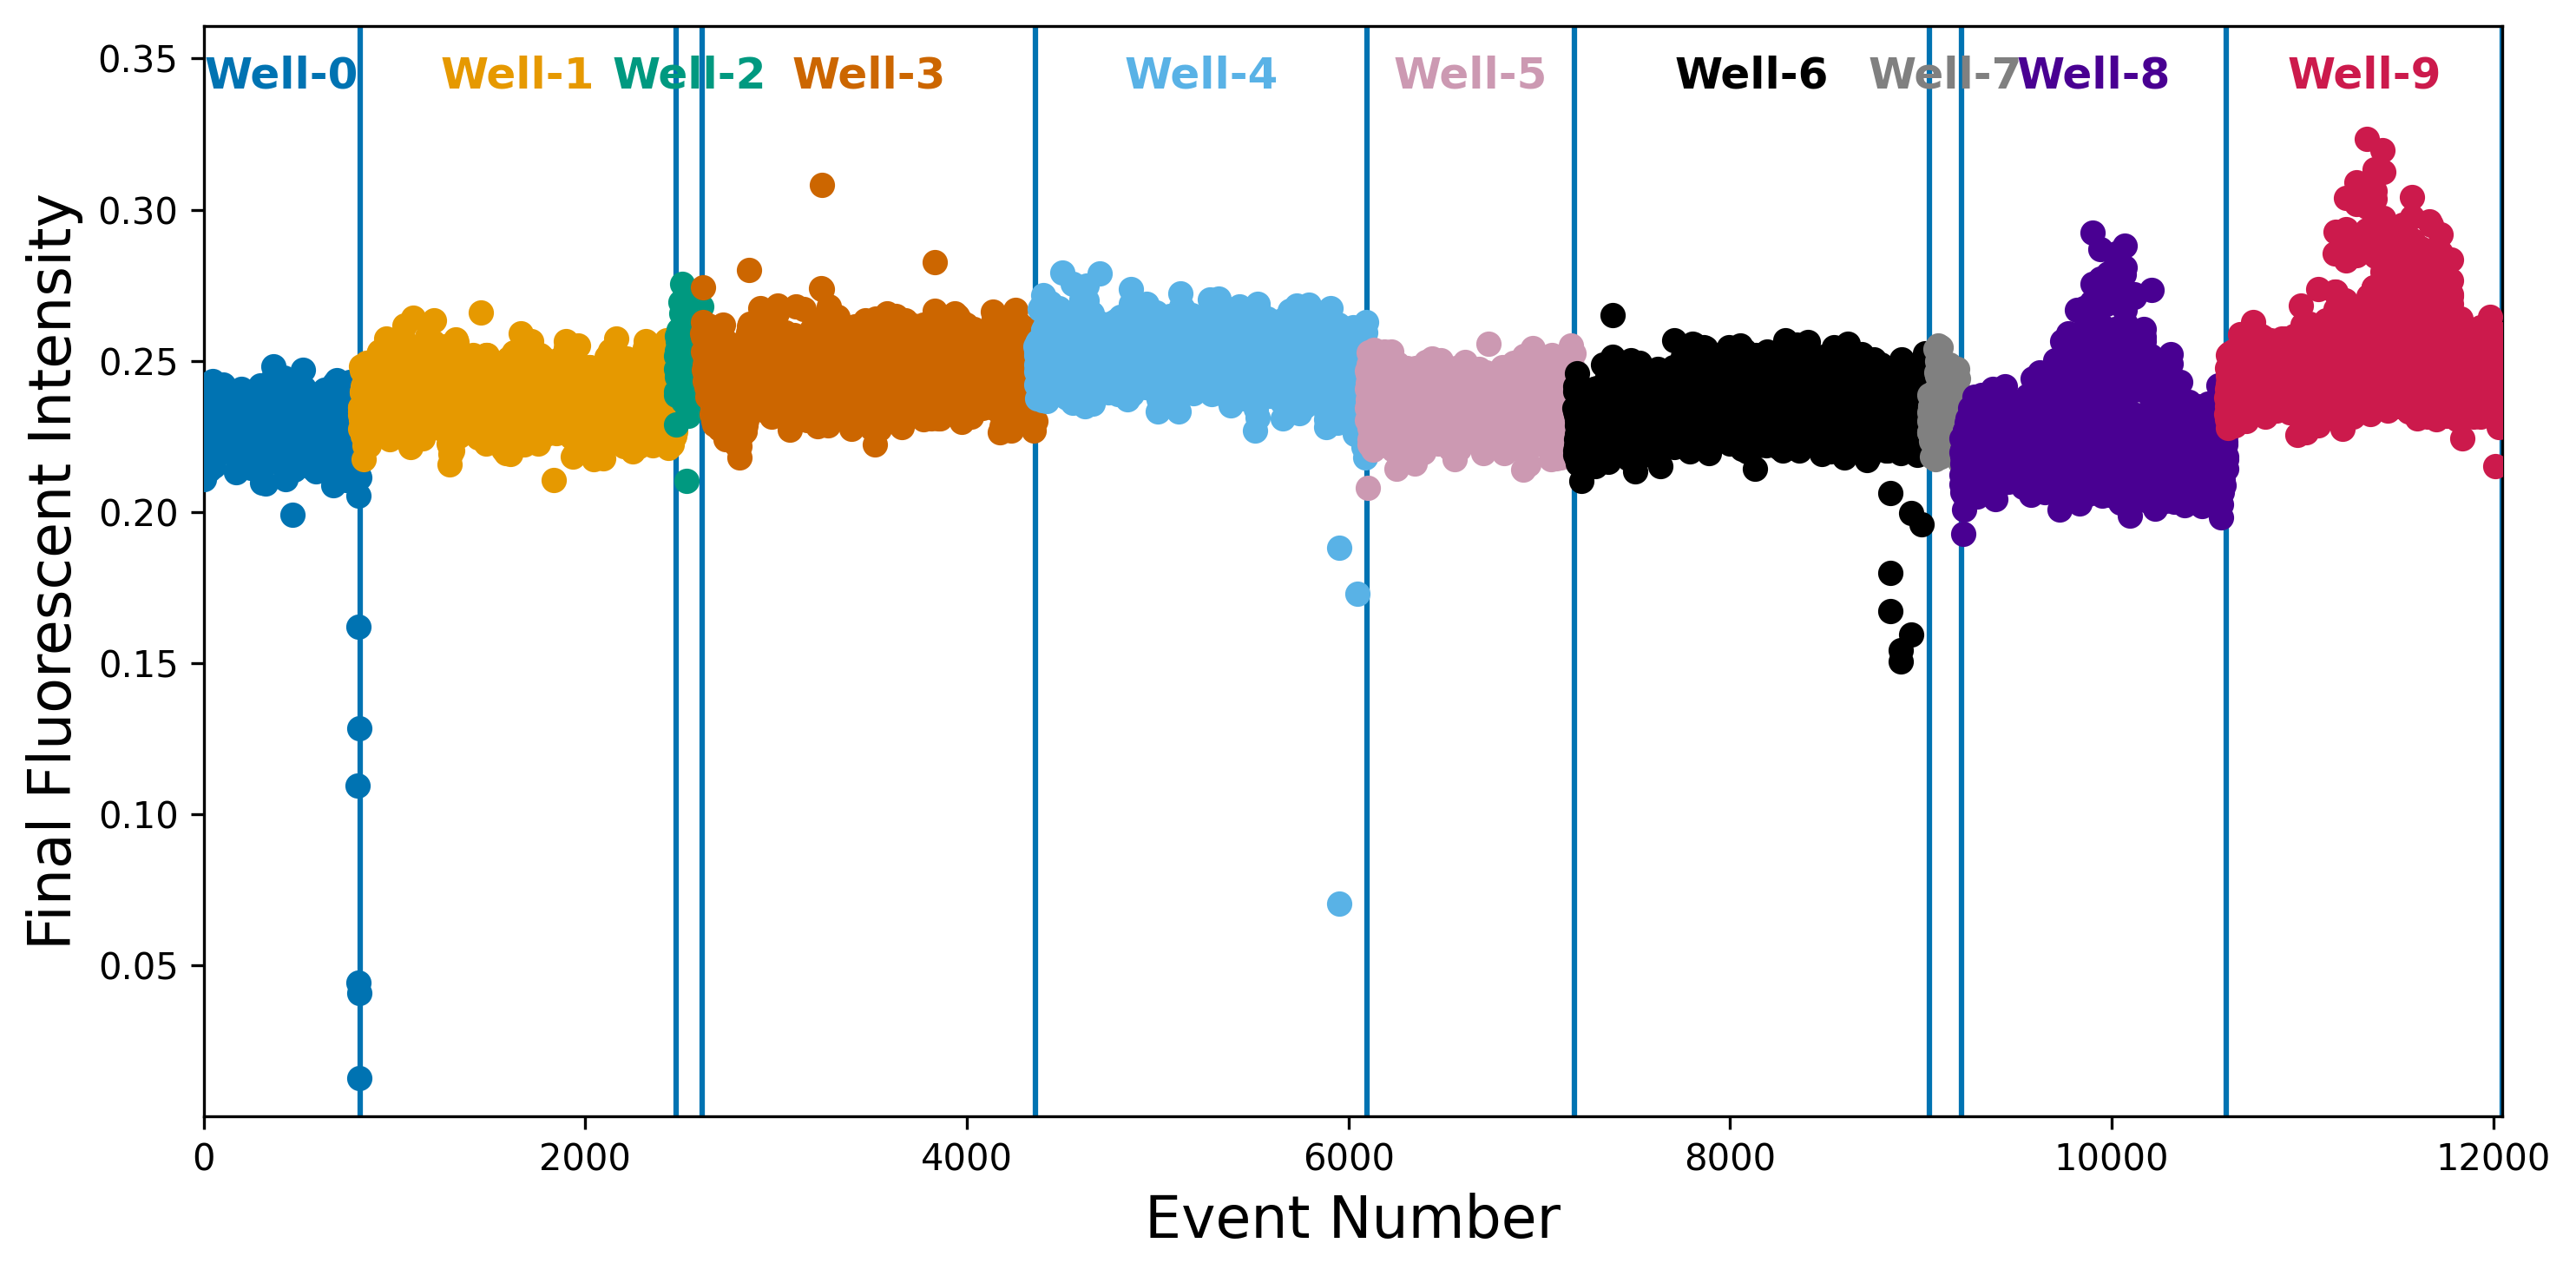

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5), dpi=300)

cnt = 0
for i in np.unique(ytrue):
    idx = ytrue==i
    ax.scatter(np.arange(np.sum(idx)) + cnt, X_FFI[idx], color=f'C{i}', zorder=100)
    
    ax.text(cnt + np.sum(idx)/2, y_lim_max*1.05, f"Well-{encoder.classes_[i]}", color=f'C{i}', fontsize=12, weight='bold',
            horizontalalignment='center', verticalalignment='center')
    
    cnt += np.sum(idx)
    
    ax.vlines(cnt, y_lim_min, y_lim_max*1.1)
    
    
ax.set_xlim((0, len(X_FFI)))
ax.set_ylim((y_lim_min, y_lim_max*1.1))

ax.set_ylabel('Final Fluorescent Intensity', fontsize=16)
ax.set_xlabel('Event Number', fontsize=16)

# ax.grid(True)

plt.tight_layout()
# plt.savefig('Images/dPCR_FFI_Dist.png')
plt.show()

## Define ACA Model (Neural Network)

In [11]:
import tensorflow as tf
from scikeras.wrappers import KerasClassifier

class myWrapper(KerasClassifier):
    # def predict(self, X):
    #     return self.model.predict(X).argmax(axis=1)
    
    # def predict_proba(self, X):
    #     return self.model.predict(X)
    pass

display(f'TF VERSION: {tf.__version__}')

def create_model(): # 70% WE USED FOR THE FIRST TIME TNSOR BOARD
    # TIMESTEPS, CHANNELS
    inputs = tf.keras.layers.Input(shape=(X_AC.shape[1], 1))
    x = tf.keras.layers.Conv1D(16, 5, activation='relu')(inputs)
    x = tf.keras.layers.Conv1D(8, 3, activation='relu')(x)
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(len(np.unique(ytrue)), activation='softmax')(x)
    model = tf.keras.models.Model(inputs=inputs, outputs=x)
    model.compile(optimizer='adam', 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])
    return model

tf_net = create_model()
tf_net.summary()

'TF VERSION: 2.21.0'

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 615, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 611, 16)        │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 609, 8)         │           392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4872)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        48,730 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,218 (192.26 KB)

 Trainable params: 49,218 (192.26 KB)

 Non-trainable params: 0 (0.00 B)

## Train and Compute Performance (10-Fold Cross Val)

In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multiclass import OneVsOneClassifier

N_SPLITS = 10

kfolds = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=0)
splits = kfolds.split(X_AC, ytrue)

y_trues_ = []

y_preds_AC_ = []
y_preds_AC_kNN_ = []

# y_preds_MC_ = []

y_preds_FFI_ = []

# y_preds_AMCA_ = []
# y_preds_AMCA_kNN_ = []

for i, (train_index, test_index) in enumerate(tqdm(splits, total=N_SPLITS)):

    # X_MC_train, X_MC_test = X_MC[train_index], X_MC[test_index]
    X_AC_train, X_AC_test = X_AC[train_index], X_AC[test_index]
    X_FFI_train, X_FFI_test = X_FFI[train_index], X_FFI[test_index]
    
    y_train, y_test = ytrue[train_index], ytrue[test_index]
    y_trues_.append(y_test)

    ########## create/train model for AC ##########
    clf_AC = OneVsOneClassifier(myWrapper(build_fn=create_model, 
                            epochs=1000, 
                            batch_size=512, 
                            shuffle=True,
                            verbose=False))
    clf_AC.fit(X_AC_train, y_train)
    # clf_AC_proba = clf_AC.predict_proba(X_AC_train)
    y_preds_AC_.append( clf_AC.predict(X_AC_test) )
    
    ########## create/train model for AC with KNN##########
    clf_AC_kNN = OneVsOneClassifier(KNeighborsClassifier(n_neighbors=10))
    clf_AC_kNN.fit(X_AC_train, y_train)
    # clf_AC_kNN_proba = clf_AC_kNN.predict_proba(X_AC_train)
    y_preds_AC_kNN_.append(clf_AC_kNN.predict(X_AC_test))

    # ########## create/train model for MC ##########    
    # clf_MC = LogisticRegression(max_iter=1000)
    # clf_MC.fit(X_MC_train, y_train)
    # clf_MC_proba = clf_MC.predict_proba(X_MC_train)
    # y_preds_MC_.append(clf_MC.predict(X_MC_test))

    ########## create/train model for FFI ##########
    clf_FFI = OneVsOneClassifier(LogisticRegression(max_iter=1000))
    clf_FFI.fit(X_FFI_train, y_train)
    y_preds_FFI_.append(clf_FFI.predict(X_FFI_test))

    # ########## create/train model for AMCA ##########
    # X_AMCA_train = np.concatenate((clf_MC_proba, clf_AC_proba), axis=1)
    # X_AMCA_test = np.concatenate((clf_MC.predict_proba(X_MC_test), 
    #                                clf_AC.predict_proba(X_AC_test)), axis=1)
    
    # clf_AMCA = LogisticRegression(max_iter=1000, fit_intercept=False)
    # clf_AMCA.fit(X_AMCA_train, y_train)
    # y_preds_AMCA_.append(clf_AMCA.predict(X_AMCA_test))

    # ########## create/train model for AMCA kNN ##########
    # X_AMCA_kNN_train = np.concatenate((clf_MC_proba, clf_AC_kNN_proba), axis=1)
    # X_AMCA_kNN_test = np.concatenate((clf_MC.predict_proba(X_MC_test), 
    #                                clf_AC_kNN.predict_proba(X_AC_test)), axis=1)
    
    # clf_AMCA_kNN = LogisticRegression(max_iter=1000, fit_intercept=False)
    # clf_AMCA_kNN.fit(X_AMCA_kNN_train, y_train)
    # y_preds_AMCA_kNN_.append(clf_AMCA_kNN.predict(X_AMCA_kNN_test))

    
y_trues = np.concatenate(y_trues_)

y_preds_AC = np.concatenate(y_preds_AC_)
y_preds_AC_kNN = np.concatenate(y_preds_AC_kNN_)
# y_preds_MC = np.concatenate(y_preds_MC_)
y_preds_FFI = np.concatenate(y_preds_FFI_)
# y_preds_AMCA = np.concatenate(y_preds_AMCA_)
# y_preds_AMCA_kNN = np.concatenate(y_preds_AMCA_kNN_)

  0%|          | 0/10 [00:00<?, ?it/s]/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/3. Initial code/titan-signal-processing-main/venv_titan/lib/python3.12/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/3. Initial code/titan-signal-processing-main/venv_titan/lib/python3.12/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/3. Initial code/titan-signal-processing-main/venv_titan/lib/python3.12/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renam

 10%|█         | 1/10 [1:10:14<10:32:12, 4214.67s/it]/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/3. Initial code/titan-signal-processing-main/venv_titan/lib/python3.12/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/3. Initial code/titan-signal-processing-main/venv_titan/lib/python3.12/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/3. Initial code/titan-signal-processing-main/venv_titan/lib/python3.12/site-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`

In [16]:
from sklearn.metrics import accuracy_score
import statsmodels.api as sm
from scipy.stats import bartlett, ttest_ind

acc_for_each_fold = lambda x: [accuracy_score(i, j) for i, j in zip(x, y_trues_)]

acc_dict = {'FFI': acc_for_each_fold(y_preds_FFI_),
            'ACA': acc_for_each_fold(y_preds_AC_),
            # 'MCA': acc_for_each_fold(y_preds_MC_),
            # 'AMCA': acc_for_each_fold(y_preds_)
            }
acc = pd.DataFrame(acc_dict)

normality_test = lambda x: sm.stats.lilliefors(x)[1]

# variance_test = lambda x: bartlett(x, acc['AMCA'])[1]

# ttest = lambda x: ttest_ind(x, acc['AMCA'], equal_var=False)[1]

# statistics = lambda x: [np.mean(x), np.std(x), normality_test(x), variance_test(x), ttest(x)]

# stats = pd.DataFrame({k: statistics(acc[k]) for k in acc.columns})

# stats.index = ['Mean Acc.', 'Std Acc.', 'Normality p-val.', 'Equal Var. p-val', 'Ttest p-val']

# pd.set_option('display.float_format', lambda x: f'{x:.4f}')

# stats

In [ ]:
# # pd.DataFrame({'True': y_trues,'FFI': y_preds_FFI, 'ACA': y_preds_AC, 'MCA': y_preds_MC, 'AMCA': y_preds}).to_csv('Data/my_preds.csv')
# pd.DataFrame({'True': y_trues,'FFI': y_preds_FFI, 'ACA': y_preds_AC, 'ACA_kNN': y_preds_AC_kNN}).to_csv('Data/my_preds.csv')

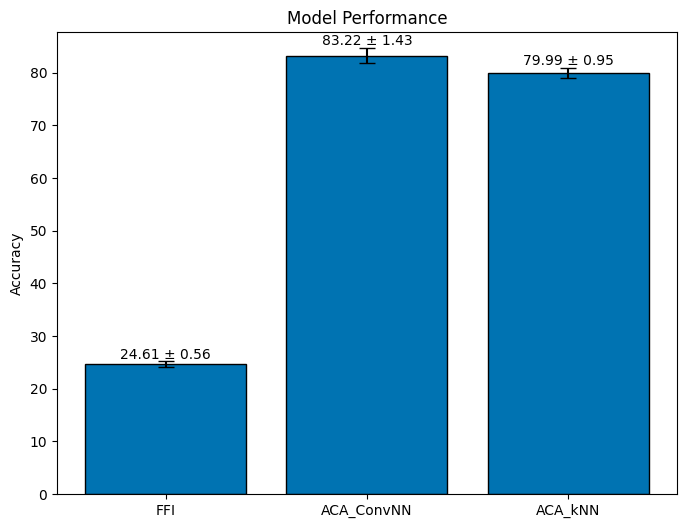

In [17]:
classes = encoder.classes_

ypreds_methods = [y_preds_FFI_, y_preds_AC_, y_preds_AC_kNN_] #, y_preds_MC_, y_preds_]
titles = ['Final Fluorescence Intensity',
          'Amplification Curve Analysis',
          'Amplification Curve Analysis (kNN)'] #,
        #   'Melting Curve Analysis',
        #   'Amplification and Melting Curve Analysis']
short_names = ['FFI', 'ACA_ConvNN', 'ACA_kNN']#, 'MCA', 'AMCA']
accs_mean = []
accs_std = []
for yps in ypreds_methods:
    acc_temp = []
    for yp, y_tr in zip(yps, y_trues_):
        acc_temp.append(accuracy_score(y_tr, yp)*100)
    accs_mean.append(np.mean(acc_temp))
    accs_std.append(np.std(acc_temp))

custom_labels = [f'{a:.2f} ± {s:.2f}' for a, s in zip(accs_mean, accs_std)]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(short_names, accs_mean, yerr=accs_std, capsize=6, edgecolor='black')
ax.bar_label(bars, labels=custom_labels, padding=0, fontsize=10)
ax.set_ylim(0, max(accs_mean) + max(accs_std) + 3)
ax.set_ylabel('Accuracy')
ax.set_title('Model Performance')

plt.show()

In [ ]:
print(short_names)
print(accs_mean)
print(accs_std)

['FFI', 'ACA_ConvNN', 'ACA_kNN']
[np.float64(26.5044664396686), np.float64(88.07187659392619), np.float64(80.06971919328382)]
[np.float64(0.718598424850021), np.float64(0.9652911361936923), np.float64(0.8943081325705065)]


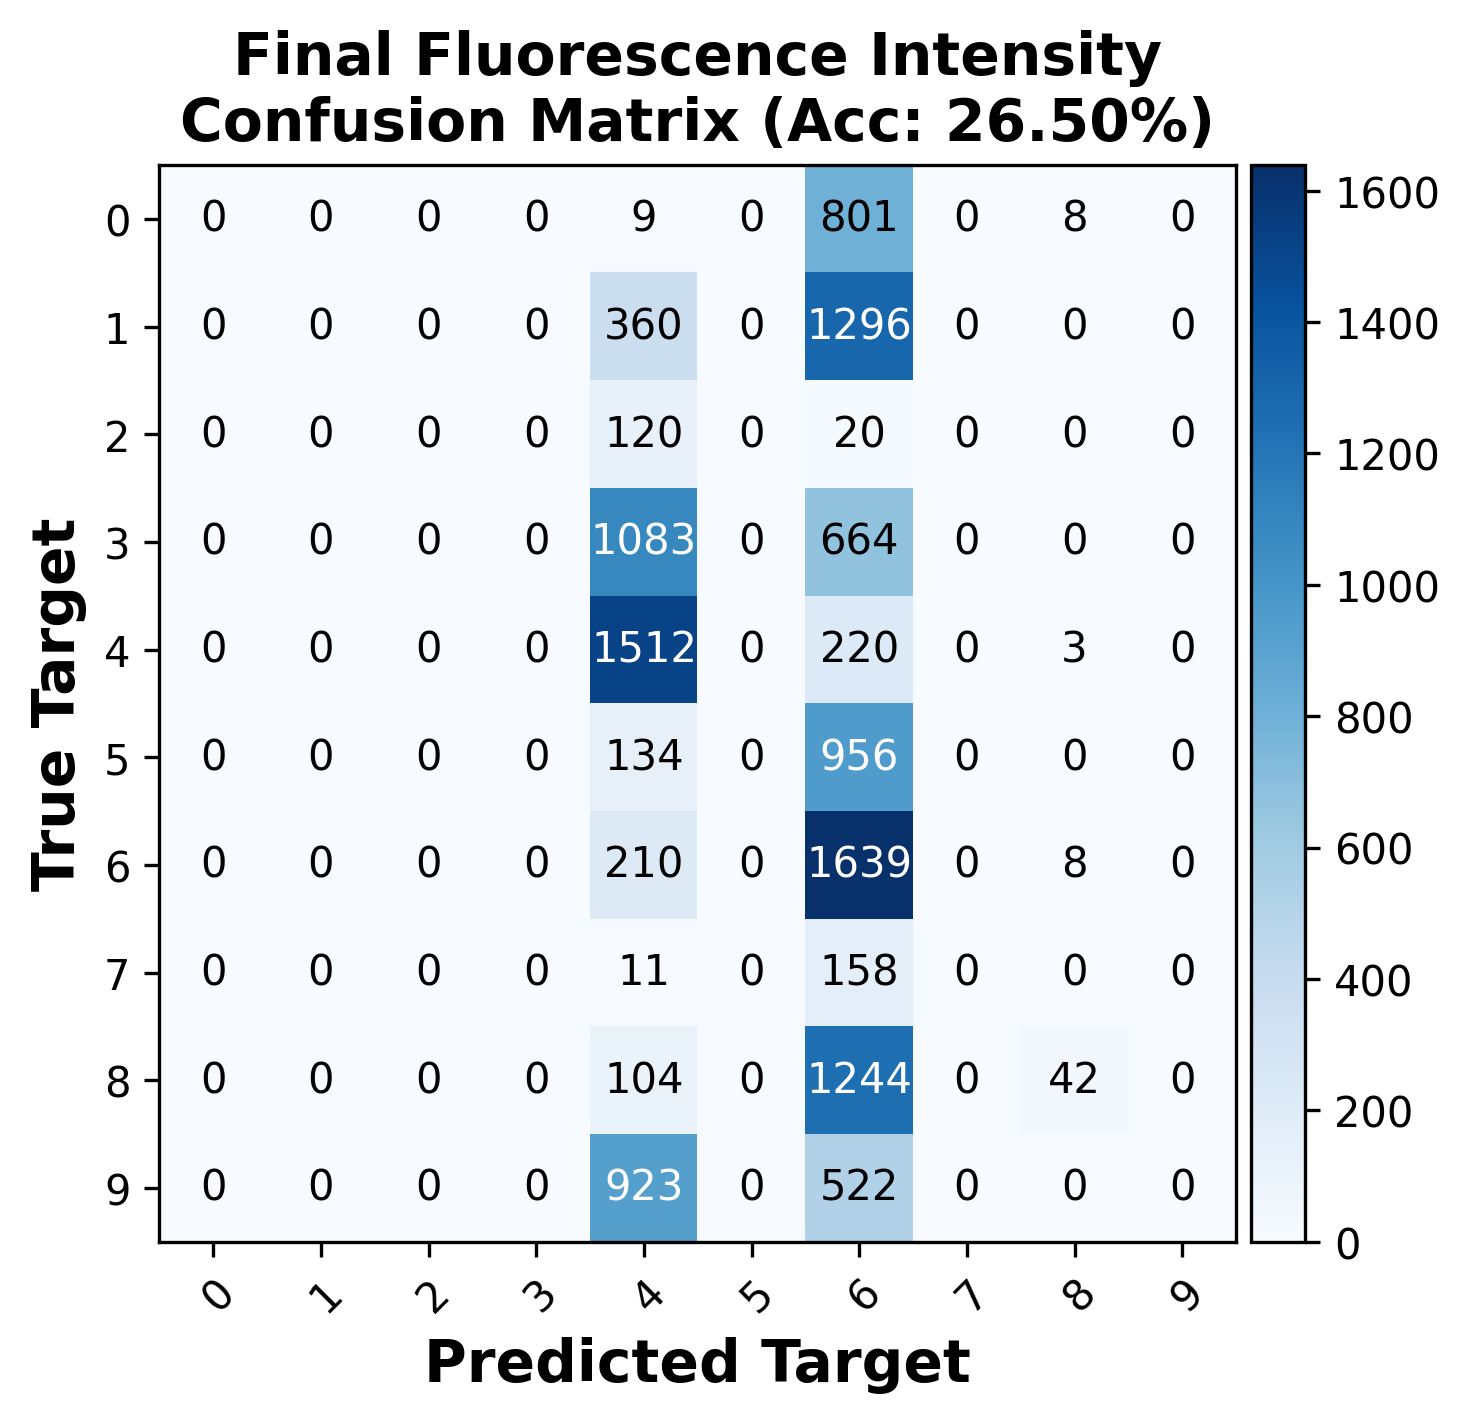

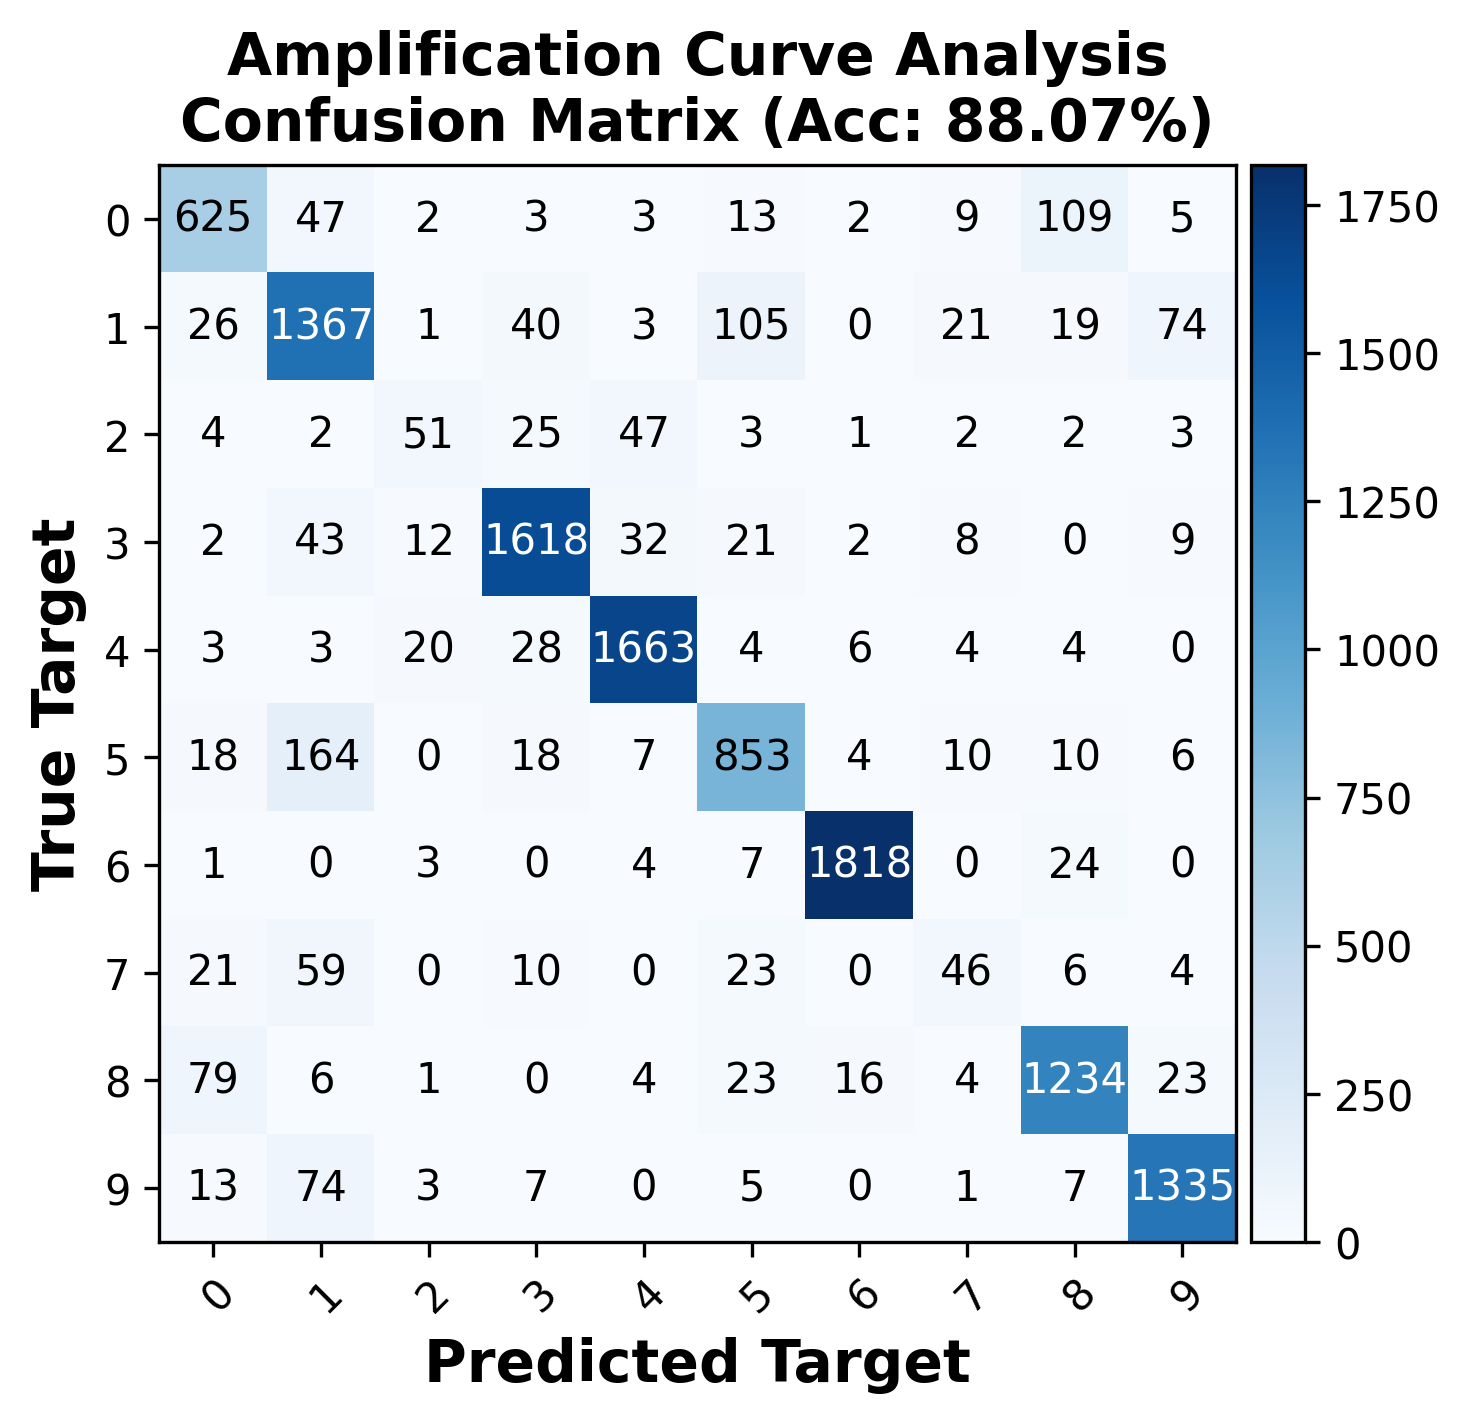

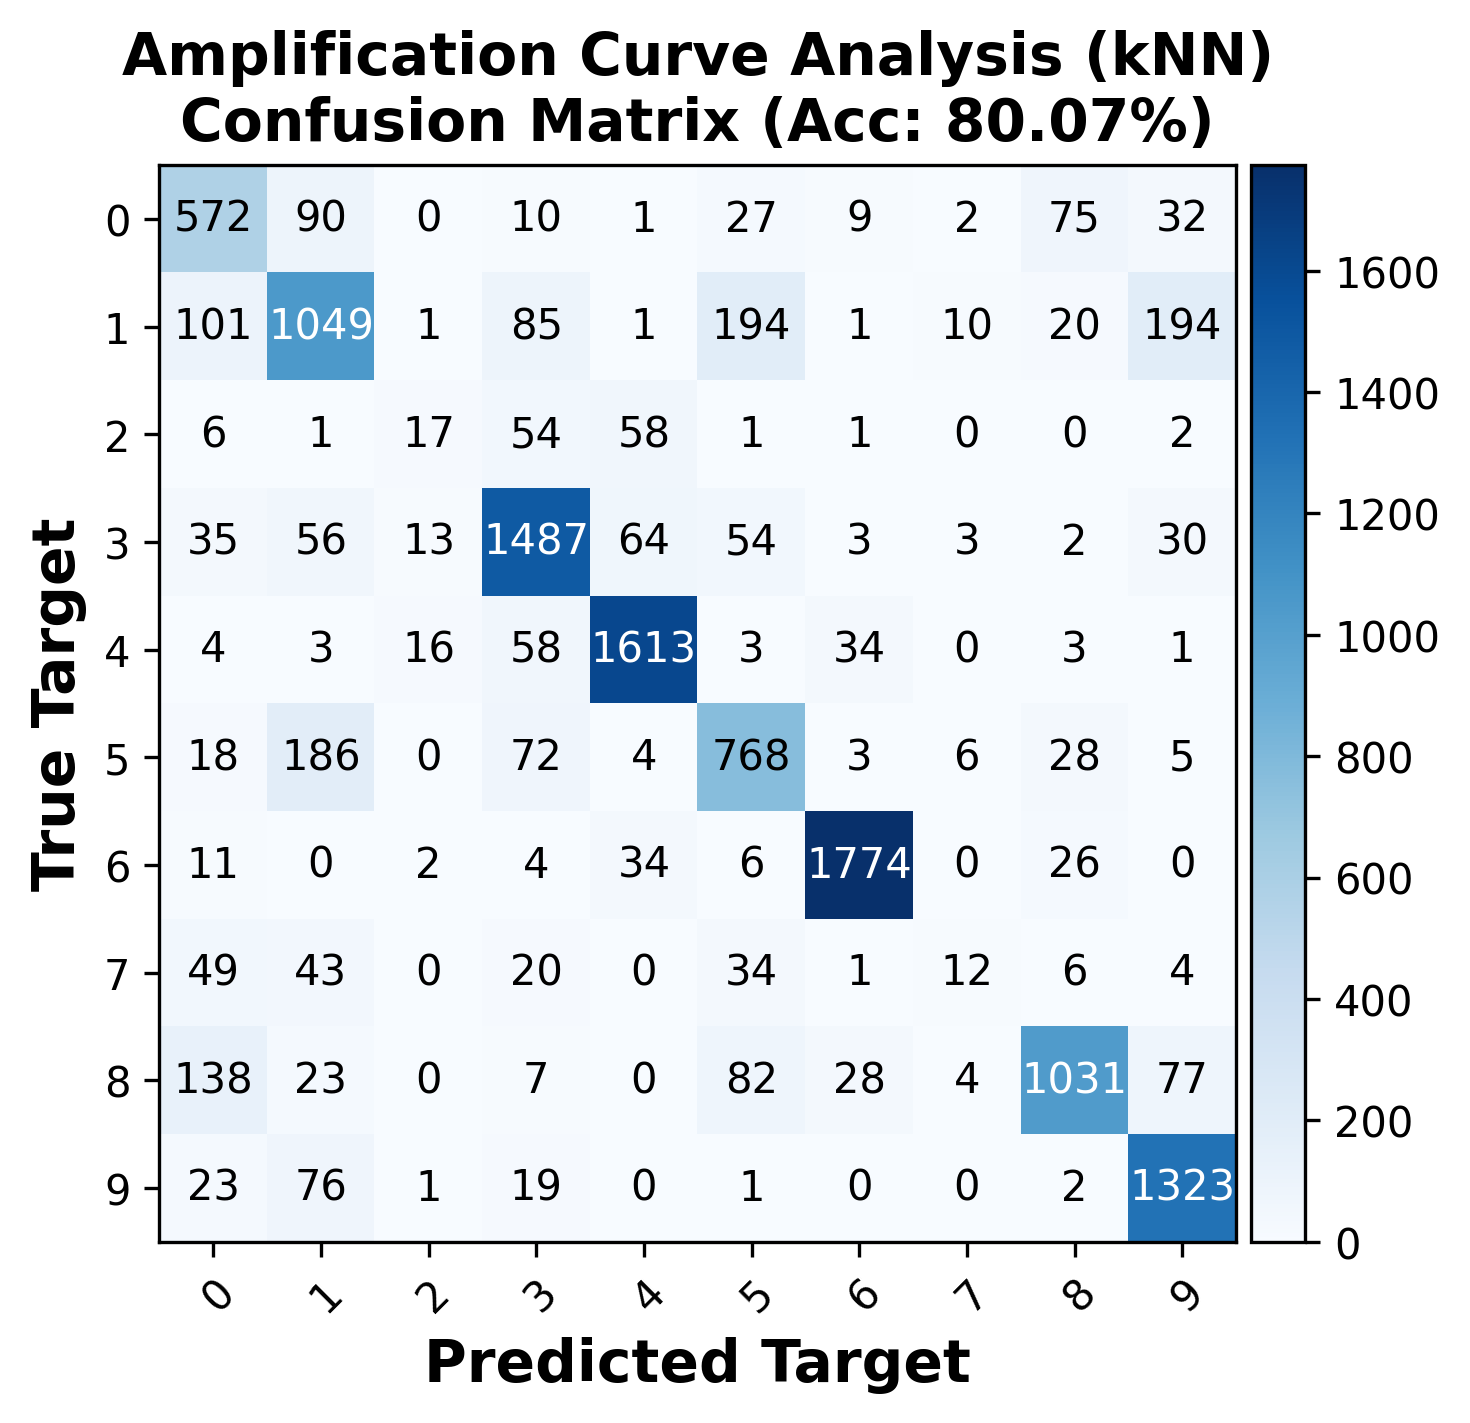

In [ ]:
classes = encoder.classes_

ypreds_methods = [y_preds_FFI, y_preds_AC, y_preds_AC_kNN] #, y_preds_MC, y_preds]
titles = ['Final Fluorescence Intensity',
          'Amplification Curve Analysis',
          'Amplification Curve Analysis (kNN)']
        #   ,
        #   'Melting Curve Analysis',
        #   'Amplification and Melting Curve Analysis']
short_names = ['FFI', 'ACA_ConvNN', 'ACA_kNN'] #, 'MCA', 'AMCA']

for yp, title, short_name in zip(ypreds_methods, titles, short_names):

    fig, ax = plt.subplots(1, 1, figsize=(5, 5), dpi=300)

    utils.plot_confusion_matrix(y_trues, yp, classes, ax, normalize=False)
    ax.set_title(f'{title}\n'+ax.get_title(), fontsize=14, weight='bold')
    ax.set_ylabel('True Target', fontsize=14, weight='bold')
    ax.set_xlabel('Predicted Target', fontsize=14, weight='bold')

    plt.tight_layout()
    plt.savefig(f'Images/dPCR_{short_name}.pdf')
    plt.show()